In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
import random
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers


df = pd.read_csv('processed_amazon_data.csv')

feature_cols = [
    "High", "Low", "Open", "Volume",
    "HL_Pct", "OC_Pct", "SMA_10", "SMA_30",
    "MACD", "MACD_Signal", "MACD_Hist",
    "RSI",
    "Volume_SMA_10", "Volume_Ratio",
    "Return_Lag_1", "Return_Lag_3", "Return_Lag_5"
]

df.dropna().reset_index(drop=True)

data = df[feature_cols].values
prices = df["Close"].values

In [67]:
class TradingEnv:
    def __init__(self, prices, data):
        self.prices = prices
        self.data = data
        self.n_steps = len(prices)
        self.reset()


    def reset(self):
        self.index = 0
        self.position = 0 # 0 = no position, 1 = holding stock
        self.buy_price = 0
        return self.data[self.index]


    def step(self, action):
        # 0 = hold, 1 = buy, 2 = sell
        reward = 0


        if action == 1 and self.position == 0: # buy
            self.position = 1
            self.buy_price = self.prices[self.index]
        elif action == 2 and self.position == 1: # sell
            reward = self.prices[self.index] - self.buy_price
            self.position = 0


        self.index += 1
        done = self.index >= self.n_steps - 1
        next_state = self.data[self.index] if not done else np.zeros_like(self.data[0])


        return next_state, reward, done

In [68]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=5000)


        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995
        self.lr = 0.001


        self.model = self.build_model()


    def build_model(self):
        model = models.Sequential([
            layers.Dense(32, activation='relu', input_shape=(self.state_size,)),
            layers.Dense(32, activation='relu'),
            layers.Dense(self.action_size)
        ])
        model.compile(optimizer=optimizers.Adam(self.lr), loss='mse')
        return model


    def act(self, state):
        if np.random.rand() < self.epsilon:
            return random.randrange(self.action_size)
        q_values = self.model.predict(state[np.newaxis], verbose=0)
        return np.argmax(q_values[0])


    def remember(self, s, a, r, ns, done):
        self.memory.append((s, a, r, ns, done))


    def replay(self, batch_size=32):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)


        states, targets = [], []


        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                target += self.gamma * np.amax(self.model.predict(next_state[np.newaxis], verbose=0)[0])


            q_values = self.model.predict(state[np.newaxis], verbose=0)[0]
            q_values[action] = target


            states.append(state)
            targets.append(q_values)


        self.model.train_on_batch(np.array(states), np.array(targets))


        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

In [69]:
state_size = data.shape[1]
action_size = 3 # hold, buy, sell
agent = DQNAgent(state_size, action_size)


env = TradingEnv(prices, data)


episodes = 5
max_steps = 500
batch_size = 32


for ep in range(episodes):
    state = env.reset()
    total_reward = 0
    steps = 0

    while True:
        action = agent.act(state)
        next_state, reward, done = env.step(action)
        agent.remember(state, action, reward, next_state, done)


        state = next_state
        total_reward += reward
        steps += 1


        if steps % 10 == 0:
            agent.replay(batch_size)


        if done or steps >= max_steps:
            break


    print(f"Episode {ep+1}/{episodes} - Total Reward: {total_reward:.2f} - Epsilon: {agent.epsilon:.3f}")

c:\Users\shivv\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Episode 1/5 - Total Reward: -26.94 - Epsilon: 0.914
Episode 2/5 - Total Reward: 26.45 - Epsilon: 0.822
Episode 3/5 - Total Reward: -3.76 - Epsilon: 0.740
Episode 4/5 - Total Reward: 25.26 - Epsilon: 0.666
Episode 5/5 - Total Reward: -16.33 - Epsilon: 0.600


In [70]:
def simulate_agent(agent, env, initial_cash=10000):
    """
    Runs a full simulation using the trained agent.
    Returns equity curve (list of portfolio values).
    """

    # Reset the environment
    state = env.reset()
    
    cash = initial_cash
    shares = 0
    equity_curve = []

    while True:
        # Choose action (no exploration)
        action = np.argmax(agent.model.predict(state.reshape(1, -1), verbose=0))

        price = env.prices[env.index]

        # BUY
        if action == 1 and shares == 0:
            shares = cash / price
            cash = 0

        # SELL
        elif action == 2 and shares > 0:
            cash = shares * price
            shares = 0

        # Track portfolio value
        portfolio_value = cash + shares * price
        equity_curve.append(portfolio_value)

        # Step the environment
        next_state, reward, done = env.step(action)
        state = next_state

        if done:
            # Final portfolio value
            final_value = cash + shares * price
            equity_curve.append(final_value)
            break

    return np.array(equity_curve)


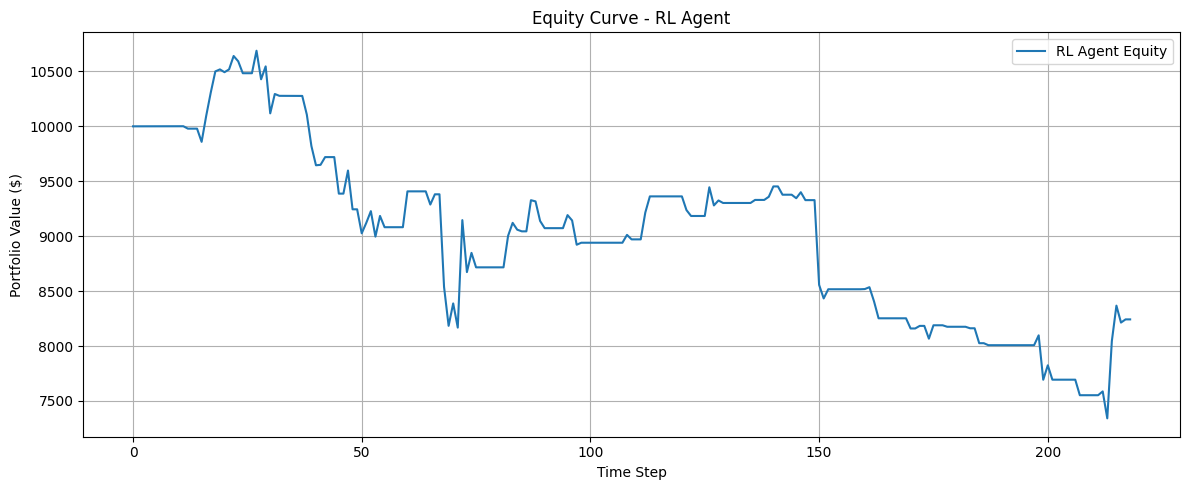

In [71]:
equity = simulate_agent(agent, env)

plt.figure(figsize=(12,5))
plt.plot(equity, label="RL Agent Equity")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value ($)")
plt.title("Equity Curve - RL Agent")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [72]:
def evaluate_performance(equity_curve, buy_sell_log=None, risk_free_rate=0.0):
    """
    equity_curve: np.array of portfolio values from simulate_agent()
    buy_sell_log: list of tuples (action, price) from simulate_agent() if available
    """
    
    equity = np.array(equity_curve)
    returns = np.diff(equity) / equity[:-1]   # percent returns between steps

    # Final return
    total_return = (equity[-1] / equity[0]) - 1

    # Max Drawdown
    running_max = np.maximum.accumulate(equity)
    drawdown = (equity - running_max) / running_max
    max_drawdown = drawdown.min()

    # Volatility
    volatility = returns.std()

    # Sharpe Ratio (risk-free often assumed 0)
    sharpe_ratio = (returns.mean() - risk_free_rate) / (volatility + 1e-9)

    # If buy/sell data exists:
    num_trades = None
    win_rate = None
    profit_factor = None
    avg_win = None
    avg_loss = None

    if buy_sell_log is not None:
        # buy_sell_log format: [("BUY", price), ("SELL", price, profit), ...]
        sell_profits = [p[2] for p in buy_sell_log if p[0] == "SELL"]
        
        num_trades = len(sell_profits)
        
        wins = [p for p in sell_profits if p > 0]
        losses = [p for p in sell_profits if p <= 0]

        win_rate = len(wins) / num_trades if num_trades > 0 else 0
        avg_win = np.mean(wins) if len(wins) > 0 else 0
        avg_loss = np.mean(losses) if len(losses) > 0 else 0

        if sum(p for p in wins) == 0 or sum(abs(p) for p in losses) == 0:
            profit_factor = None
        else:
            profit_factor = sum(wins) / (sum(abs(l) for l in losses) + 1e-9)

    return {
        "Total Return (%)": total_return * 100,
        "Max Drawdown (%)": max_drawdown * 100,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe_ratio,
    }

metrics = evaluate_performance(equity)

# Print the results
for k, v in metrics.items():
    print(f"{k}: {v}")

Total Return (%): -17.572611648226754
Max Drawdown (%): -31.307610668364237
Volatility: 0.018174668764605682
Sharpe Ratio: -0.03972670213262878
